# Preparing Environment

In [1]:
import numpy as np
import pandas as pd
import openpyxl
import re
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
pd.set_option('display.max_columns', 200)

In [2]:
covariates = ["sex"]
covariates.extend([f"comorb_selfreport_{i}" for i in range(1, 21)])
symptoms = [f"currentsymptoms_{i}" for i in range(1, 47)]
symptoms.extend(["eq5vas"])

In [3]:
# symptom to currentsymptom mapping
file_ = open('symptoms_sinai.txt','r')
symptoms = file_.readlines()[:44]
file_.close()
symptoms = [val.lower().replace("\n", "") for val in symptoms]
print(len(symptoms), "symptoms")
symptoms_dict = dict(zip(["currentsymptoms_" + str(i) for i in range(1, len(symptoms) + 1)], symptoms))
print(symptoms_dict)

44 symptoms
{'currentsymptoms_1': 'fever or chills', 'currentsymptoms_2': 'headache', 'currentsymptoms_3': 'abnormal changes in body temperature', 'currentsymptoms_4': 'unexplained sweats or flushing', 'currentsymptoms_5': 'problems seeing (double or blurry vision)', 'currentsymptoms_6': 'difficulty hearing', 'currentsymptoms_7': 'tinnitus (ringing in the ears)', 'currentsymptoms_8': 'loss of smell', 'currentsymptoms_9': 'loss of taste', 'currentsymptoms_10': 'difficulty swallowing', 'currentsymptoms_11': 'cough', 'currentsymptoms_12': 'sore throat', 'currentsymptoms_13': 'shortness of breath', 'currentsymptoms_14': 'breathing faster than normal', 'currentsymptoms_15': 'fatigue or tiredness', 'currentsymptoms_16': 'chest pain or discomfort', 'currentsymptoms_17': 'heart palpitations, pulse skips, heart block', 'currentsymptoms_18': 'dizziness or lightheadedness', 'currentsymptoms_19': 'fainting or blackouts', 'currentsymptoms_20': 'diarrhea', 'currentsymptoms_21': 'nausea', 'currentsym

# Loading Data

In [4]:
# # Most recent data
# file = "data_from_collaborators/UCSF_2_4_25_most_recent_surveys_partial.xlsx"
file = "data_from_collaborators/UCSF_2_4_25_most_recent_surveys_100_.xlsx"
file = openpyxl.load_workbook(file, data_only = True)
print(file.sheetnames)
sheet = "Sheet1"
data = pd.DataFrame(file[sheet].values)
data = data.fillna(float("nan"))
data.columns = [val.replace(" ", "_").lower() for val in data.iloc[0,:]]
data = data.iloc[1:, :].reset_index(drop = True)
data = data.rename(columns = {"comorb_selfreport_v2___13": "comorb_selfreport_13"})
data

['Sheet1']


,record_id,todaydate,yale_id,diet_0,diet_1,diet_2,diet_3,diet_4,diet_5,diet_6,diet_7,foodallergy,foodallergy2,physicalactivity_1,physicalactivity_2,dvt,heartattack,stroke,pulmembolism,kidney,liver,recovered,disability,disability_approval,currentsymptoms_1,currentsymptoms_2,currentsymptoms_3,currentsymptoms_4,currentsymptoms_5,currentsymptoms_6,currentsymptoms_7,currentsymptoms_8,currentsymptoms_9,currentsymptoms_10,currentsymptoms_11,currentsymptoms_12,currentsymptoms_13,currentsymptoms_14,currentsymptoms_15,currentsymptoms_16,currentsymptoms_17,currentsymptoms_18,currentsymptoms_19,currentsymptoms_20,currentsymptoms_21,currentsymptoms_22,currentsymptoms_23,currentsymptoms_24,currentsymptoms_25,currentsymptoms_26,currentsymptoms_27,currentsymptoms_28,currentsymptoms_29,currentsymptoms_30,currentsymptoms_31,currentsymptoms_32,currentsymptoms_33,currentsymptoms_34,currentsymptoms_35,currentsymptoms_36,currentsymptoms_37,currentsymptoms_38,currentsymptoms_39,currentsymptoms_40,currentsymptoms_41,currentsymptoms_42,currentsymptoms_43,currentsymptoms_44,currentsymptoms_45,currentsymptoms_46,exacerbation_1,exacerbation_2,exacerbation_3,exacerbation_4,exacerbation_5,exacerbation_6,exacerbation_7,exacerbation_8,exacerbation_9,exacerbation_10,exacerbation_11,exacerbation_12,eq5_1,eq5_2,eq5_3,eq5_4,eq5_5,eq5vas,gender_0,gender_1,gender_2,gender_3,gender_4,gender_5,hispanic,race,comorb_selfreport_1,comorb_selfreport_2,comorb_selfreport_3,comorb_selfreport_4,...,oxysupport,hospital_covid,hospital_admission,hospital_discharge,icu,invasiv_vent,pacs_treatments___0,pacs_treatments___1,pacs_treatments___2,pacs_treatments___3,pacs_treatments___4,pacs_treatments___5,pacs_treatments___6,pacs_treatments___7,pacs_treatments___8,pacs_treatments___9,pacs_treatments___10,pacs_treatments___11,pacs_treatments___12,date_pacstreatment,meds_supps_1___1,meds_supps_1___2,meds_supps_1___3,meds_supps_1___4,meds_supps_1___5,meds_supps_1___6,meds_supps_2,covid_date,trans_horm1,trans_horm2,covid19_pain,education,initialcovidsymptomdate,symptomduration,covid_symptoms___1,covid_symptoms___2,covid_symptoms___3,covid_symptoms___4,covid_symptoms___5,covid_symptoms___6,covid_symptoms___7,covid_symptoms___8,covid_symptoms___9,covid_symptoms___10,covid_symptoms___11,covid_symptoms___12,covid_symptoms___13,covid_symptoms___14,covid_symptoms___15,covid_symptoms___16,covid_symptoms___17,covid_symptoms___18,covid_symptoms___19,covid_symptoms___20,covid_symptoms___21,covid_symptoms___22,covid_symptoms___23,covid_symptoms___24,covid_symptoms___25,covid_symptoms___26,covid_symptoms___27,covid_symptoms___28,covid_symptoms___29,covid_symptoms___30,covid_symptoms___31,covid_symptoms___32,covid_symptoms___33,covid_symptoms___34,covid_symptoms___35,covid_symptoms___36,covid_symptoms___37,covid_symptoms___38,covid_symptoms___39,covid_symptoms___40,covid_symptoms___41,covid_symptoms___42,covid_symptoms___43,covid_symptoms___44,covid_symptoms___45,covid_symptoms___46,other_symptom,age,gender,race___1,race___2,race___3,race___4,race___5,race___6,occupation,primary_language,language_other,maritalstatus,living_count,med_insur,type_medinsur___1,type_medinsur___2,type_medinsur___3,survey_complete,source
0,2,2021-07-20 00:00:00,79,0,0,0,0,0,0,1,1,0,NaN,1,1,0,0,0,0,0,0,NaN,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,1,1,0,1,0,0,0,0,0,1,2,2,1,2,75,0,1,0,0,0,0,0,2,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,0,1,1,1,0,0,0,0,0,0,2020-08-01 00:00:00,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Follow2
1,3,2021-03-15 00:00:00,NaN,1,0,0,0,0,0,0,0,0,NaN,2,3,0,0,0,0,0,0,0,0,NaN,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,NaN,NaN,

In [5]:
print(data.shape)
data[["survey_complete", "source"]].value_counts()

(825, 330)


survey_complete  source         
2                Original Survey    433
                 Follow2            283
                 Follow1            108
                 Follow1+Consent      1
dtype: int64

In [6]:
print(len(np.unique(data["record_id"].astype(str))))
print(len(np.unique(data["yale_id"].astype(str))))

825
135


In [7]:
subset = data[[f"currentsymptoms_{i}" for i in range(1, 45)]]
print(subset.shape)
subset["sum"] = subset.sum(axis = 1)
subset["record_id"] = data["record_id"]
subset["yale_id"] = data["yale_id"]
columns = ["record_id", "yale_id", "sum"]
columns.extend([f"currentsymptoms_{i}" for i in range(1, 45)])
subset = subset[columns]
subset

(825, 44)


C:\Users\bpeng\AppData\Local\Temp\ipykernel_24304\820330483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["sum"] = subset.sum(axis = 1)
C:\Users\bpeng\AppData\Local\Temp\ipykernel_24304\820330483.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["record_id"] = data["record_id"]
C:\Users\bpeng\AppData\Local\Temp\ipykernel_24304\820330483.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

,record_id,yale_id,sum,currentsymptoms_1,currentsymptoms_2,currentsymptoms_3,currentsymptoms_4,currentsymptoms_5,currentsymptoms_6,currentsymptoms_7,currentsymptoms_8,currentsymptoms_9,currentsymptoms_10,currentsymptoms_11,currentsymptoms_12,currentsymptoms_13,currentsymptoms_14,currentsymptoms_15,currentsymptoms_16,currentsymptoms_17,currentsymptoms_18,currentsymptoms_19,currentsymptoms_20,currentsymptoms_21,currentsymptoms_22,currentsymptoms_23,currentsymptoms_24,currentsymptoms_25,currentsymptoms_26,currentsymptoms_27,currentsymptoms_28,currentsymptoms_29,currentsymptoms_30,currentsymptoms_31,currentsymptoms_32,currentsymptoms_33,currentsymptoms_34,currentsymptoms_35,currentsymptoms_36,currentsymptoms_37,currentsymptoms_38,currentsymptoms_39,currentsymptoms_40,currentsymptoms_41,currentsymptoms_42,currentsymptoms_43,currentsymptoms_44
0,2,79,8.0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1
1,3,NaN,9.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0
2,7,NaN,23.0,0,1,0,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,1,1,0,1,0,0,1,1,1,1,1,1,1,0,1,1,0,1,0,1,0,0,1,1,0
3,8,NaN,7.0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0
4,9,NaN,14.0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,1,1,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,1272,NaN,3.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
821,1273,NaN,9.0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
822,1274,NaN,10.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,1,0
823,1275,NaN,15.0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,1,1,1,0,1,0,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0


In [8]:
subset[subset["sum"] == 0]

,record_id,yale_id,sum,currentsymptoms_1,currentsymptoms_2,currentsymptoms_3,currentsymptoms_4,currentsymptoms_5,currentsymptoms_6,currentsymptoms_7,currentsymptoms_8,currentsymptoms_9,currentsymptoms_10,currentsymptoms_11,currentsymptoms_12,currentsymptoms_13,currentsymptoms_14,currentsymptoms_15,currentsymptoms_16,currentsymptoms_17,currentsymptoms_18,currentsymptoms_19,currentsymptoms_20,currentsymptoms_21,currentsymptoms_22,currentsymptoms_23,currentsymptoms_24,currentsymptoms_25,currentsymptoms_26,currentsymptoms_27,currentsymptoms_28,currentsymptoms_29,currentsymptoms_30,currentsymptoms_31,currentsymptoms_32,currentsymptoms_33,currentsymptoms_34,currentsymptoms_35,currentsymptoms_36,currentsymptoms_37,currentsymptoms_38,currentsymptoms_39,currentsymptoms_40,currentsymptoms_41,currentsymptoms_42,currentsymptoms_43,currentsymptoms_44
30,51,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
50,84,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
94,157,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
112,185,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
123,198,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
234,352,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
324,490,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
609,963,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
783,1232,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
# # # Old data
# # file = "data_from_collaborators/export_dataframe.xlsx"
# # file = 'data_from_collaborators/UCSF_6_27_2024_DATAEXPORT.xlsx'
# # file = 'data_from_collaborators/UCSF_8_8_2024_DATAEXPORT.xlsx'
# # file = 'data_from_collaborators/UCSF_8_21_2024_DATAEXPORT.xlsx'zz
# file = 'data_from_collaborators/UCSF_11_12_2024_DATAEXPORT_yale_id.xlsx'
# file = openpyxl.load_workbook(file, data_only = True)
# print(file.sheetnames)
# sheet = "Sheet1"
# data = pd.DataFrame(file[sheet].values)
# data = data.fillna(float("nan"))
# data.columns = [val.replace(" ", "_").lower() for val in data.iloc[0,:]]
# data = data.iloc[1:, :].reset_index(drop = True)
# data = data.rename(columns = {"comorb_selfreport_v2___13": "comorb_selfreport_13"})
# data

In [10]:
# Sex info
sex_df = "data_from_collaborators/Gender_LONG_COVID_BREAKDOWN_v2.xlsx"
sex_df = openpyxl.load_workbook(sex_df, data_only = True)
sex_df = pd.DataFrame(sex_df["Sheet1"].values)
sex_df = sex_df.fillna(float("nan"))
sex_df.columns = [str(val).replace(" ", "_").lower() for val in sex_df.iloc[0,:]]
sex_df = sex_df.iloc[1:, :4]
values = []
for index, row in sex_df[["sex_at_birth/_gender", "gender", "gender_-_filled"]].iterrows(): 
    value = "_".join([str(val).lower() for val in row])
    value = value.replace("nan", "").replace("_", "")
    if "trans" in value: value = "female" # 1275_female_trans male
    if value in ["female", "femalefemale"]: value = "F"
    elif value in ["male", "malemale"]: value = "M"
    else: value = float("nan")
    values.append(value)
sex_df["sex"] = values
data = data.merge(sex_df[["record_id", "sex"]], on = "record_id")
data["sex"].value_counts()

F    566
M    241
Name: sex, dtype: int64

In [11]:
# Value counts for all survey_complete and source
data["source"] = data["source"].astype("category")
data["source"] = data["source"].cat.set_categories(["Original Survey", "Follow1", "Follow1+Consent", "Follow2"])
dict(data[["survey_complete", "source"]].value_counts())

{(2, 'Original Survey'): 433,
 (2, 'Follow2'): 283,
 (2, 'Follow1'): 108,
 (2, 'Follow1+Consent'): 1}

In [12]:
subset = data[data["eq5vas"] > 0][["record_id", "survey_complete", "source", "eq5vas"]]
subset = subset[subset["survey_complete"] == 2]
# subset = subset[subset.duplicated("record_id", keep = False)]
subset["source2"] = ["Original Survey" if val == "Original Survey" else "FollowUp" for val in subset["source"]]
print(len(np.unique(subset["record_id"])))
print(subset["source2"].value_counts())
subset = subset.groupby(["record_id", "source2"]).mean().reset_index().sort_values(["record_id", "source2"])
# clusters = [11, 1, 1, 10, 11, 13, 11, 13, 10, 1, 11, 1, 11, 11, 1, 1, 13, 11, 1, 1, 1, 11, 1, 10, 1, 11, 1, 11, 11, 13, 13, 10, 10, 10, 1, 13, 11, 11, 13, 13, 13, 11, 13, 13, 10, 1, 1, 11, 1, 11, 11, 1, 13, 11, 10, 10, 1, 8, 10, 11, 1, 13, 11, 10, 10, 16, 1, 1, 1, 13, 10, 1, 13, 13, 13, 10, 11, 13, 13, 13, 13, 10, 10, 10, 10, 1, 1, 1, 10, 10, 8, 13, 3, 1, 1, 1, 9, 11, 1, 11, 13, 1, 11, 1, 1, 11, 2, 1, 1, 3, 1, 1, 12, 1, 1, 3, 1, 1, 2, 1, 8, 1, 1, 6, 2, 3, 7, 3, 16, 5, 1, 7, 4, 1, 4, 1, 4, 16, 1, 1, 3, 4, 4, 7, 4, 4, 1, 1, 7, 8, 1, 2, 1, 12, 2, 1, 6, 14, 2, 1, 7, 1, 1, 12, 4, 15, 2, 1, 1, 5, 8, 14, 12, 2, 8, 1, 5, 1, 1, 1, 1, 16, 1, 1, 1, 1, 8, 6, 7, 3, 10, 5, 1, 7, 1, 2, 1, 1, 16, 1, 1, 1, 5, 1, 7, 1, 3, 4, 6, 1, 1, 1, 2, 14, 9, 6, 1, 1, 9, 1, 6, 4, 6, 1, 1, 1, 1, 1, 5, 3, 1, 7, 1, 3, 6, 2, 1, 1, 2, 1, 6, 10, 1, 14, 1, 2, 8, 1, 1, 1, 1, 4, 2, 5, 9, 2, 1, 15, 4, 9, 6, 1, 1, 16, 3, 3, 1, 1, 1, 2, 1, 12, 2, 2, 6, 1, 2, 9, 14, 1, 8, 2, 1, 3, 1, 4, 1, 6, 3, 6, 16, 9, 2, 1, 4, 1, 1, 1, 1, 1, 12, 1, 14, 4, 1, 9, 4, 1, 1, 6, 3, 1, 6, 4, 6, 1, 2, 1, 7, 14, 14, 1, 2, 2, 1, 2, 1, 14, 2, 5, 1, 14, 7, 2, 1, 1, 1, 1, 1, 9, 5, 1, 3, 3, 12, 4, 12, 3, 3, 5, 1, 1, 5, 1, 2, 2, 3, 2, 10, 12, 7, 5, 1, 1, 8, 3, 9, 1, 1, 12, 1, 8, 7, 1, 1, 1, 5, 15, 1, 15, 7, 7, 5, 2, 7, 6, 6, 12, 6, 6, 10, 1, 2, 1, 1, 5, 14, 6, 1, 4, 1, 4, 1, 8, 14, 1, 1, 1, 1, 5, 7, 1, 5, 6, 12, 8, 8, 3, 15, 1, 14, 1, 5, 6, 7, 14, 1, 1, 4, 1, 1, 14, 12, 9, 7, 3, 1, 6, 15, 5, 3, 1, 8, 12, 6, 12, 7, 1, 8, 15, 1, 12, 2, 5, 1, 3, 1, 6, 1, 4, 1, 8, 5, 3, 9, 5, 9, 4, 2, 2, 1, 3, 8, 15, 1, 5, 1, 3, 2, 9, 6, 14, 12, 8, 5, 5, 6, 16, 14, 1, 3, 6, 6, 2, 15, 8, 1, 2, 7, 9, 8, 16, 7, 3, 5, 3, 1, 3, 3, 1, 8, 14, 2, 8, 1, 5, 8, 3, 9, 1, 4, 1, 2, 4, 9, 4, 1, 4, 1, 12, 1, 5, 1, 2, 9, 3, 5, 7, 9, 9, 1, 5, 1, 1, 1, 7, 9, 12, 3, 1, 9, 4, 15, 2, 5, 1, 7, 5, 3, 1, 6, 4, 12, 4, 2, 5, 9, 8, 6, 1, 6, 1, 1, 12, 7, 4, 4, 12, 5, 1, 1, 15, 2, 3, 15, 7, 1, 6, 1, 2, 4, 5, 12, 5, 3, 1, 4, 14, 7, 10, 14, 8, 14, 1, 1, 5, 4, 1, 1, 9, 6, 2, 4, 7, 14, 4, 3, 7, 9, 2, 7, 16, 3, 6, 1, 16, 4, 1, 7, 3, 2, 12, 1, 1, 7, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 2, 7, 1, 1, 1, 1, 1, 1, 1, 1, 7, 1, 1, 1, 1, 1, 1, 8, 8, 1, 16, 1, 2, 3]
# clusters_dict = dict(zip(subset["record_id"], clusters))
clusters_dict = {9: 11, 11: 1, 12: 1, 13: 10, 14: 11, 19: 13, 20: 11, 22: 13, 29: 10, 31: 1, 32: 11, 33: 1, 39: 11, 42: 11, 44: 1, 46: 1, 49: 13, 50: 11, 56: 1, 58: 1, 63: 1, 65: 11, 67: 1, 69: 10, 71: 1, 72: 11, 73: 1, 74: 11, 77: 11, 78: 13, 79: 13, 80: 10, 82: 10, 83: 10, 86: 1, 88: 13, 90: 11, 91: 11, 92: 13, 93: 13, 98: 13, 99: 11, 101: 13, 102: 13, 103: 10, 104: 1, 111: 1, 112: 11, 115: 1, 116: 11, 117: 11, 121: 1, 122: 13, 123: 11, 124: 10, 125: 10, 126: 1, 130: 8, 131: 10, 132: 11, 133: 1, 138: 13, 141: 11, 142: 10, 143: 10, 148: 16, 149: 1, 151: 1, 153: 1, 154: 13, 156: 10, 157: 1, 158: 13, 160: 13, 161: 13, 162: 10, 164: 11, 169: 13, 171: 13, 173: 13, 175: 13, 176: 10, 177: 10, 179: 10, 181: 10, 182: 1, 185: 1, 186: 1, 187: 10, 188: 10, 189: 8, 190: 13, 194: 3, 195: 1, 198: 1, 199: 1, 202: 9, 203: 11, 204: 1, 208: 11, 211: 13, 213: 1, 214: 11, 215: 1, 216: 1, 218: 11, 222: 2, 223: 1, 224: 1, 225: 3, 226: 1, 227: 1, 228: 12, 230: 1, 232: 1, 233: 3, 234: 1, 235: 1, 236: 2, 238: 1, 242: 8, 243: 1, 244: 1, 246: 6, 248: 2, 252: 3, 253: 7, 255: 3, 256: 16, 258: 5, 261: 1, 262: 7, 264: 4, 266: 1, 267: 4, 268: 1, 269: 4, 270: 16, 271: 1, 272: 1, 273: 3, 274: 4, 276: 4, 279: 7, 280: 4, 281: 4, 282: 1, 284: 1, 286: 7, 287: 8, 288: 1, 290: 2, 291: 1, 292: 12, 297: 2, 299: 1, 302: 6, 303: 14, 304: 2, 305: 1, 306: 7, 307: 1, 312: 1, 313: 12, 315: 4, 318: 15, 319: 2, 320: 1, 321: 1, 325: 5, 328: 8, 329: 14, 331: 12, 332: 2, 333: 8, 336: 1, 337: 5, 340: 1, 345: 1, 348: 1, 349: 1, 350: 16, 352: 1, 353: 1, 356: 1, 358: 1, 359: 8, 361: 6, 362: 7, 363: 3, 364: 10, 367: 5, 370: 1, 373: 7, 374: 1, 375: 2, 376: 1, 377: 1, 379: 16, 380: 1, 381: 1, 383: 1, 384: 5, 387: 1, 388: 7, 390: 1, 391: 3, 392: 4, 395: 6, 396: 1, 400: 1, 403: 1, 405: 2, 406: 14, 409: 9, 410: 6, 411: 1, 415: 1, 417: 9, 419: 1, 420: 6, 421: 4, 422: 6, 423: 1, 425: 1, 426: 1, 427: 1, 428: 1, 429: 5, 430: 3, 433: 1, 437: 7, 438: 1, 439: 3, 441: 6, 445: 2, 446: 1, 450: 1, 451: 2, 453: 1, 454: 6, 455: 10, 456: 1, 457: 14, 458: 1, 459: 2, 460: 8, 462: 1, 463: 1, 464: 1, 465: 1, 466: 4, 467: 2, 468: 5, 469: 9, 471: 2, 474: 1, 477: 15, 479: 4, 480: 9, 482: 6, 483: 1, 485: 1, 486: 16, 487: 3, 488: 3, 490: 1, 492: 1, 495: 1, 497: 2, 500: 1, 501: 12, 503: 2, 504: 2, 506: 6, 511: 1, 512: 2, 514: 9, 515: 14, 516: 1, 519: 8, 520: 2, 522: 1, 523: 3, 526: 1, 528: 4, 529: 1, 530: 6, 535: 3, 536: 6, 539: 16, 540: 9, 542: 2, 543: 1, 545: 4, 546: 1, 547: 1, 549: 1, 557: 1, 558: 1, 559: 12, 561: 1, 563: 14, 565: 4, 567: 1, 569: 9, 570: 4, 573: 1, 577: 1, 578: 6, 579: 3, 580: 1, 582: 6, 584: 4, 585: 6, 586: 1, 587: 2, 590: 1, 594: 7, 596: 14, 599: 14, 604: 1, 609: 2, 612: 2, 615: 1, 616: 2, 617: 1, 621: 14, 622: 2, 623: 5, 624: 1, 625: 14, 627: 7, 631: 2, 632: 1, 633: 1, 635: 1, 637: 1, 639: 1, 640: 9, 644: 5, 645: 1, 646: 3, 647: 3, 650: 12, 651: 4, 652: 12, 654: 3, 655: 3, 657: 5, 658: 1, 659: 1, 663: 5, 666: 1, 669: 2, 673: 2, 674: 3, 677: 2, 678: 10, 679: 12, 680: 7, 681: 5, 682: 1, 684: 1, 687: 8, 689: 3, 691: 9, 692: 1, 698: 1, 702: 12, 703: 1, 706: 8, 710: 7, 711: 1, 712: 1, 713: 1, 714: 5, 715: 15, 716: 1, 717: 15, 718: 7, 719: 7, 721: 5, 722: 2, 723: 7, 724: 6, 725: 6, 728: 12, 737: 6, 739: 6, 740: 10, 743: 1, 744: 2, 747: 1, 748: 1, 749: 5, 751: 14, 752: 6, 754: 1, 755: 4, 756: 1, 758: 4, 759: 1, 760: 8, 761: 14, 764: 1, 766: 1, 770: 1, 771: 1, 773: 5, 774: 7, 775: 1, 776: 5, 778: 6, 779: 12, 781: 8, 782: 8, 783: 3, 784: 15, 786: 1, 788: 14, 789: 1, 793: 5, 794: 6, 795: 7, 797: 14, 800: 1, 801: 1, 802: 4, 803: 1, 804: 1, 805: 14, 806: 12, 808: 9, 809: 7, 810: 3, 811: 1, 813: 6, 814: 15, 815: 5, 816: 3, 817: 1, 818: 8, 819: 12, 820: 6, 821: 12, 822: 7, 823: 1, 824: 8, 825: 15, 826: 1, 828: 12, 830: 2, 831: 5, 832: 1, 833: 3, 837: 1, 838: 6, 839: 1, 840: 4, 841: 1, 842: 8, 843: 5, 844: 3, 846: 9, 847: 5, 848: 9, 851: 4, 852: 2, 854: 2, 855: 1, 859: 3, 860: 8, 861: 15, 864: 1, 865: 5, 866: 1, 867: 3, 869: 2, 871: 9, 872: 6, 873: 14, 877: 12, 878: 8, 879: 5, 880: 5, 883: 6, 884: 16, 886: 14, 887: 1, 892: 3, 893: 6, 895: 6, 896: 2, 897: 15, 898: 8, 899: 1, 902: 2, 904: 7, 911: 9, 912: 8, 913: 16, 915: 7, 916: 3, 917: 5, 919: 3, 920: 1, 921: 3, 922: 3, 923: 1, 928: 8, 931: 14, 933: 2, 936: 8, 937: 1, 941: 5, 943: 8, 944: 3, 947: 9, 948: 1, 949: 4, 950: 1, 952: 2, 953: 4, 960: 9, 961: 4, 963: 1, 967: 4, 968: 1, 969: 12, 975: 1, 977: 5, 982: 1, 984: 2, 986: 9, 988: 3, 991: 5, 994: 7, 995: 9, 997: 9, 998: 1, 999: 5, 1000: 1, 1001: 1, 1005: 1, 1007: 7, 1009: 9, 1010: 12, 1014: 3, 1016: 1, 1017: 9, 1021: 4, 1023: 15, 1026: 2, 1027: 5, 1028: 1, 1033: 7, 1039: 5, 1042: 3, 1043: 1, 1045: 6, 1050: 4, 1060: 12, 1061: 4, 1062: 2, 1069: 5, 1070: 9, 1071: 8, 1076: 6, 1078: 1, 1080: 6, 1084: 1, 1085: 1, 1086: 12, 1089: 7, 1090: 4, 1091: 4, 1092: 12, 1094: 5, 1095: 1, 1096: 1, 1097: 15, 1100: 2, 1102: 3, 1105: 15, 1106: 7, 1107: 1, 1109: 6, 1113: 1, 1118: 2, 1119: 4, 1120: 5, 1121: 12, 1126: 5, 1127: 3, 1128: 1, 1129: 4, 1131: 14, 1133: 7, 1134: 10, 1136: 14, 1141: 8, 1142: 14, 1152: 1, 1156: 1, 1157: 5, 1158: 4, 1159: 1, 1161: 1, 1175: 9, 1177: 6, 1181: 2, 1183: 4, 1188: 7, 1193: 14, 3633: 4, 7191: 3, 7283: 7, 7385: 9, 7415: 2, 7423: 7, 7424: 16, 7426: 3, 7010: 6, 7023: 1, 7024: 16, 7030: 4, 7033: 1, 7034: 7, 7032: 3, 7053: 2, 7069: 12, 7075: 1, 7076: 1, 7077: 7, 7090: 1, 3198: 1, 3199: 1, 3231: 1, 3232: 1, 3234: 1, 3260: 1, 3264: 1, 3290: 5, 3292: 1, 3299: 1, 3320: 1, 3322: 1, 3323: 1, 3324: 1, 3339: 1, 3341: 2, 3346: 7, 3362: 1, 3365: 1, 3381: 1, 3386: 1, 3391: 1, 3400: 1, 3401: 1, 3404: 1, 3427: 7, 3438: 1, 3459: 1, 3460: 1, 3471: 1, 3474: 1, 3475: 1, 3503: 8, 3532: 8}
endo_dict = {1:0, 2:1, 3:1, 4:2, 5:3, 6:2, 7:1, 8:4, 9:5, 10:7, 11:7, 12:5, 13:7, 14:5, 15:5, 16:6}
subset = subset[subset["record_id"].isin(list(clusters_dict))]
subset["cluster"] = [clusters_dict[val] for val in subset["record_id"]]
subset["endotype"] = ["E" + str(endo_dict[val]) for val in subset["cluster"]]
subset["cluster"] = ["C" + str(val) for val in subset["cluster"]]
subset = subset.sort_values("source2", ascending = False)
subset

819
Original Survey    428
FollowUp           391
Name: source2, dtype: int64


C:\Users\bpeng\AppData\Local\Temp\ipykernel_24304\3561606584.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  subset = subset.groupby(["record_id", "source2"]).mean().reset_index().sort_values(["record_id", "source2"])


,record_id,source2,survey_complete,eq5vas,cluster,endotype
749,1193,Original Survey,2.0,58.0,C14,E5
359,558,Original Survey,2.0,80.0,C1,E0
356,547,Original Survey,2.0,85.0,C1,E0
355,546,Original Survey,2.0,90.0,C1,E0
354,545,Original Survey,2.0,40.0,C4,E2
...,...,...,...,...,...,...
241,367,FollowUp,2.0,65.0,C5,E3
238,362,FollowUp,2.0,23.0,C7,E1
237,361,FollowUp,2.0,40.0,C6,E2
234,358,FollowUp,2.0,40.0,C1,E0


In [13]:
subset = data[data["survey_complete"] == 2]
subset["source"].value_counts()

Original Survey    433
Follow2            283
Follow1            108
Follow1+Consent      1
Name: source, dtype: int64

In [14]:
subset = data[data["survey_complete"] == 2].copy()
del subset["currentsymptoms_45"]
del subset["currentsymptoms_46"]
#[["record_id", "survey_complete", "source", "eq5vas"]]
# subset = subset[~subset.duplicated("record_id", keep = False)]
subset["source2"] = ["Original Survey" if val == "Original Survey" else "FollowUp" for val in subset["source"]]
print(len(np.unique(subset["record_id"])))
print(subset["source2"].value_counts())
columns = ["record_id", "sex", "source", "source2"]
columns.extend(list(filter(re.compile("currentsymptoms_.*").match, subset.columns)))
subset = subset[columns].rename(columns = symptoms_dict)
subset = subset.groupby(["record_id", "sex", "source2"]).mean().reset_index()
subset = subset.sort_values(["record_id", "source2"], ascending = [True, False]).reset_index(drop = True)
subset["source2"] = [1 if val == "Original Survey" else 2 for val in subset["source2"]]
subset = subset.pivot(index = ["record_id", "sex"], columns = "source2").reset_index()
columns = []
for col in subset.columns: 
    if "record_id" == col[0] or "sex" == col[0]: 
        columns.append(col[0])
    else: 
        columns.append(str(col[1]) + "_" + col[0])
subset.columns = columns
del subset["record_id"]
subset

C:\Users\bpeng\AppData\Local\Temp\ipykernel_24304\1898026104.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset["source2"] = ["Original Survey" if val == "Original Survey" else "FollowUp" for val in subset["source"]]


825
Original Survey    433
FollowUp           392
Name: source2, dtype: int64


C:\Users\bpeng\AppData\Local\Temp\ipykernel_24304\1898026104.py:12: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  subset = subset.groupby(["record_id", "sex", "source2"]).mean().reset_index()


,sex,1_fever or chills,2_fever or chills,1_headache,2_headache,1_abnormal changes in body temperature,2_abnormal changes in body temperature,1_unexplained sweats or flushing,2_unexplained sweats or flushing,1_problems seeing (double or blurry vision),2_problems seeing (double or blurry vision),1_difficulty hearing,2_difficulty hearing,1_tinnitus (ringing in the ears),2_tinnitus (ringing in the ears),1_loss of smell,2_loss of smell,1_loss of taste,2_loss of taste,1_difficulty swallowing,2_difficulty swallowing,1_cough,2_cough,1_sore throat,2_sore throat,1_shortness of breath,2_shortness of breath,1_breathing faster than normal,2_breathing faster than normal,1_fatigue or tiredness,2_fatigue or tiredness,1_chest pain or discomfort,2_chest pain or discomfort,"1_heart palpitations, pulse skips, heart block","2_heart palpitations, pulse skips, heart block",1_dizziness or lightheadedness,2_dizziness or lightheadedness,1_fainting or blackouts,2_fainting or blackouts,1_diarrhea,2_diarrhea,1_nausea,2_nausea,1_vomiting,2_vomiting,"1_indigestion or esophageal/""acid"" reflux","2_indigestion or esophageal/""acid"" reflux",1_loss of appetite or unexplained weight loss,2_loss of appetite or unexplained weight loss,1_bloating,2_bloating,1_abdominal pain,2_abdominal pain,"1_difficulty with concentration or reading or ""brain fog""","2_difficulty with concentration or reading or ""brain fog""","1_confusion, difficulty thinking","2_confusion, difficulty thinking",1_disorientation: getting lost; going to wrong places,2_disorientation: getting lost; going to wrong places,1_memory problems or forgetfulness,2_memory problems or forgetfulness,1_general/muscle weakness,2_general/muscle weakness,1_muscle pain or cramps,2_muscle pain or cramps,1_joint pain or swelling,2_joint pain or swelling,1_tingling and numbness in the mouth and/or face,2_tingling and numbness in the mouth and/or face,"1_tingling, numbness, burning, stabbing or ""pins and needles""","2_tingling, numbness, burning, stabbing or ""pins and needles""",1_swelling,2_swelling,1_urinary incontinence or difficulty urinating,2_urinary incontinence or difficulty urinating,1_unexplained menstrual irregularity,2_unexplained menstrual irregularity,1_sexual dysfunction or loss of libido,2_sexual dysfunction or loss of libido,1_unexplained hair loss,2_unexplained hair loss,1_skin lesions (rash or lumpy lesions),2_skin lesions (rash or lumpy lesions),"1_difficulty sleeping (too much, too little, early awakening)","2_difficulty sleeping (too much, too little, early awakening)","1_mood swings, irritability, depression","2_mood swings, irritability, depression",1_exaggerated symptoms or worse hangover from alcohol,2_exaggerated symptoms or worse hangover from alcohol
0,M,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,1.0
1,F,NaN,0.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0
2,M,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,0.0
3,F,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN

In [15]:
dictionary = {sex + "_" + key: [] for key in symptoms for sex in ["F", "M"]}
df = pd.DataFrame()
maximum = 0
for symptom in symptoms: 
    for sex in ["F", "M"]: 
        for i in [1, 2]: 
            values = np.array(subset[subset["sex"] == sex][str(i) + "_" + symptom])
            values = values[~np.isnan(values)]
            dictionary[sex + "_" + symptom].append(round(100*sum(values)/len(values), 0))
        df[sex + "_" + symptom] = dictionary[sex + "_" + symptom]
        if maximum < max(dictionary[sex + "_" + symptom]): 
            maximum = max(dictionary[sex + "_" + symptom])
df
dictionary

{'F_fever or chills': [11.0, 15.0],
 'M_fever or chills': [5.0, 11.0],
 'F_headache': [51.0, 66.0],
 'M_headache': [46.0, 48.0],
 'F_abnormal changes in body temperature': [30.0, 40.0],
 'M_abnormal changes in body temperature': [15.0, 23.0],
 'F_unexplained sweats or flushing': [34.0, 35.0],
 'M_unexplained sweats or flushing': [10.0, 23.0],
 'F_problems seeing (double or blurry vision)': [29.0, 30.0],
 'M_problems seeing (double or blurry vision)': [18.0, 26.0],
 'F_difficulty hearing': [14.0, 11.0],
 'M_difficulty hearing': [10.0, 9.0],
 'F_tinnitus (ringing in the ears)': [28.0, 30.0],
 'M_tinnitus (ringing in the ears)': [29.0, 30.0],
 'F_loss of smell': [19.0, 16.0],
 'M_loss of smell': [13.0, 11.0],
 'F_loss of taste': [22.0, 15.0],
 'M_loss of taste': [14.0, 7.0],
 'F_difficulty swallowing': [11.0, 12.0],
 'M_difficulty swallowing': [8.0, 9.0],
 'F_cough': [23.0, 20.0],
 'M_cough': [16.0, 13.0],
 'F_sore throat': [19.0, 22.0],
 'M_sore throat': [10.0, 17.0],
 'F_shortness of br

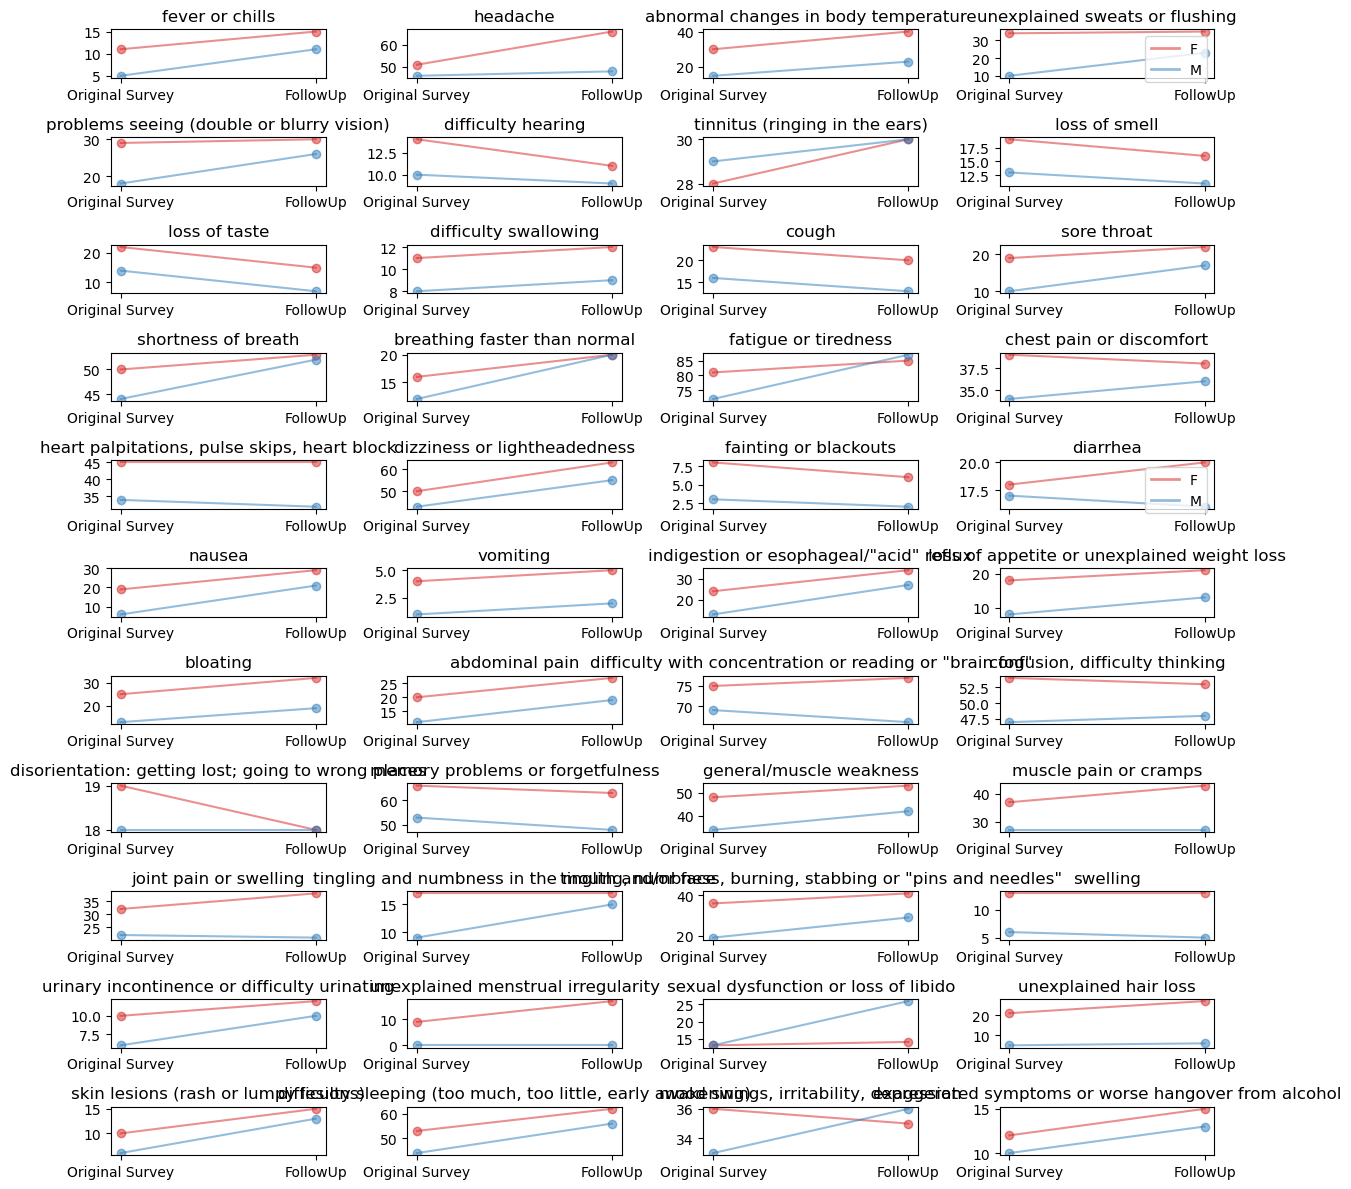

In [16]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
fig, axes = plt.subplots(11, 4, figsize = (12, 12))
colors = [sns.color_palette("Reds")[4:5][0], sns.color_palette("Blues")[4:5][0]]
legend_elements = [Line2D([0], [0], color=colors[0], lw=2, label='F', alpha = 0.5),
                   Line2D([0], [0], color=colors[1], lw=2, label='M', alpha = 0.5)]
ct = 0
for i in range(11): 
    for j in range(4): 
        axes[i, j].plot(df["F_" + symptoms[ct]], color = colors[0], marker = "o", alpha = 0.5) # linestyle = "dashed"
        axes[i, j].plot(df["M_" + symptoms[ct]], color = colors[1], marker = "o", alpha = 0.5)
        axes[i, j].set_xticks(np.arange(2), ["Original Survey", "FollowUp"])
#         axes[i, j].set_ylim(0, maximum + 3)
        axes[i, j].set_title(symptoms[ct])
        if ct == 3 or ct == 19: axes[i, j].legend(handles=legend_elements, loc='upper right')
        ct += 1
plt.tight_layout()
plt.show()

In [17]:
main_columns = list(filter(re.compile("record_id|yale_id|sex").match, data.columns))
main_columns.extend(list(filter(re.compile("currentsymptoms_.*").match, data.columns)))
main_columns.extend(list(filter(re.compile("comorb_self.*").match, data.columns)))
main_columns.extend(list(filter(re.compile("eq5vas").match, data.columns)))
print(main_columns)
# for col in main_columns: 
#     print(col)
#     print(list(np.unique(data[col].astype(str))))
#     print()

['record_id', 'yale_id', 'sex', 'currentsymptoms_1', 'currentsymptoms_2', 'currentsymptoms_3', 'currentsymptoms_4', 'currentsymptoms_5', 'currentsymptoms_6', 'currentsymptoms_7', 'currentsymptoms_8', 'currentsymptoms_9', 'currentsymptoms_10', 'currentsymptoms_11', 'currentsymptoms_12', 'currentsymptoms_13', 'currentsymptoms_14', 'currentsymptoms_15', 'currentsymptoms_16', 'currentsymptoms_17', 'currentsymptoms_18', 'currentsymptoms_19', 'currentsymptoms_20', 'currentsymptoms_21', 'currentsymptoms_22', 'currentsymptoms_23', 'currentsymptoms_24', 'currentsymptoms_25', 'currentsymptoms_26', 'currentsymptoms_27', 'currentsymptoms_28', 'currentsymptoms_29', 'currentsymptoms_30', 'currentsymptoms_31', 'currentsymptoms_32', 'currentsymptoms_33', 'currentsymptoms_34', 'currentsymptoms_35', 'currentsymptoms_36', 'currentsymptoms_37', 'currentsymptoms_38', 'currentsymptoms_39', 'currentsymptoms_40', 'currentsymptoms_41', 'currentsymptoms_42', 'currentsymptoms_43', 'currentsymptoms_44', 'currents

In [18]:
# # Subsetting data to completed original surveys
# data = data[(data["survey_complete"] == 2) & (data["source"] == "Original Survey")]
data = data[main_columns]
data

,record_id,yale_id,sex,currentsymptoms_1,currentsymptoms_2,currentsymptoms_3,currentsymptoms_4,currentsymptoms_5,currentsymptoms_6,currentsymptoms_7,currentsymptoms_8,currentsymptoms_9,currentsymptoms_10,currentsymptoms_11,currentsymptoms_12,currentsymptoms_13,currentsymptoms_14,currentsymptoms_15,currentsymptoms_16,currentsymptoms_17,currentsymptoms_18,currentsymptoms_19,currentsymptoms_20,currentsymptoms_21,currentsymptoms_22,currentsymptoms_23,currentsymptoms_24,currentsymptoms_25,currentsymptoms_26,currentsymptoms_27,currentsymptoms_28,currentsymptoms_29,currentsymptoms_30,currentsymptoms_31,currentsymptoms_32,currentsymptoms_33,currentsymptoms_34,currentsymptoms_35,currentsymptoms_36,currentsymptoms_37,currentsymptoms_38,currentsymptoms_39,currentsymptoms_40,currentsymptoms_41,currentsymptoms_42,currentsymptoms_43,currentsymptoms_44,currentsymptoms_45,currentsymptoms_46,comorb_selfreport_1,comorb_selfreport_2,comorb_selfreport_3,comorb_selfreport_4,comorb_selfreport_5,comorb_selfreport_6,comorb_selfreport_7,comorb_selfreport_8,comorb_selfreport_9,comorb_selfreport_10,comorb_selfreport_11,comorb_selfreport_12,comorb_selfreport_13,comorb_selfreport_14,comorb_selfreport_15,comorb_selfreport_16,comorb_selfreport_17,comorb_selfreport_18,comorb_selfreport_19,comorb_selfreport_20,eq5vas
0,2,79,M,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,75
1,3,NaN,F,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40
2,7,NaN,M,0,1,0,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,1,1,0,1,0,0,1,1,1,1,1,1,1,0,1,1,0,1,0,1,0,0,1,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50
3,8,NaN,F,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50
4,9,NaN,F,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,1,1,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,1272,NaN,F,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,85
821,1273,NaN,M,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,7
822,1274,NaN,M,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,25
823,1275,NaN,F,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,1,1,1,0,1,0,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,71


In [21]:
len(np.unique(data["yale_id"].astype(str)))

135

In [20]:
# file = "data_cleaned/export_dataframe.csv"
# file = "data_cleaned/UCSF_6_27_2024_DATAEXPORT_original_survey.csv"
# file = "data_cleaned/UCSF_8_8_2024_DATAEXPORT_original_survey.csv"
# file = "data_cleaned/UCSF_8_21_2024_DATAEXPORT_original_survey.csv"
file = "data_cleaned/UCSF_2_4_25_most_recent_surveys_100_n825.csv"
# data.to_csv(file, index = False)